# 01 EDA: 気象庁データの確認

目的：欠損、分布、季節性、異常値を確認する

data source: https://www.data.jma.go.jp/risk/obsdl/index.php

- Specification data: https://www.data.jma.go.jp/risk/obsdl/top/help4.html
- Specification csv: https://www.data.jma.go.jp/risk/obsdl/top/help3

## 想定するデータ

この notebooks では、気象庁から取得した東京の時系列データを想定する

| カラム | 内容 |
|-|-|
| `datetime` | 観測日時 |
| `temperature` | 気温 |
| `humidity` | 相対湿度 |
| `pressure` | 現地気圧 |
| `precipitation` | 降水量 |
| `wind_direction` | 風向 |
| `wind_speed` | 風速 |
| `cloud_amount` | 雲量 |
| `weather_code` | 天気コード |

目的変数は `weather_code` とする
なので、このnotebooksでは **未来の天気コードを分類する問題** として扱う

デフォルトでは、以下のようにする

- 入力: 過去24時間の気象データから作った特徴量
- 出力: 24時間後の天気コード
- 評価: 時系列分割で未来側のデータをテストにする


## Setup

In [18]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH_MAPS = []
for year in range(2021, 2025):
    DATA_PATH_MAPS.append({
        "data1": Path(f"./data/original/tokyo-{year}-気温-相対湿度-現地気圧.csv"),
        "data2": Path(f"./data/original/tokyo-{year}-降水量-風向風速-雲量-天気.csv"),
    })


## マスターテーブルを作る

In [19]:
# 気象庁の天気コード定義
JMA_WEATHER_CODES = {
    1: "快晴",
    2: "晴れ",
    3: "薄曇",
    4: "曇",
    5: "煙霧",
    6: "砂じん嵐",
    7: "地ふぶき",
    8: "霧",
    9: "霧雨",
    10: "雨",
    11: "みぞれ",
    12: "雪",
    13: "あられ",
    14: "ひょう",
    15: "雷",
    16: "しゅう雨または止み間のある雨",
    17: "着氷性の雨",
    18: "着氷性の霧雨",
    19: "しゅう雪または止み間のある雪",
    22: "霧雪",
    23: "凍雨",
    24: "細氷",
    28: "もや",
    101: "降水またはしゅう雨性の降水"
}

# 天気コードマスターを作成
df_weather = pd.DataFrame(list(JMA_WEATHER_CODES.items()), columns=["weather_code", "weather_name"])

In [20]:
df_weather.to_csv("./data/m_weather.csv", index=False)

## Load data

In [21]:
all_df = []
for path_map in DATA_PATH_MAPS:
    data1_path = path_map["data1"]
    if not path_map["data1"].exists():
        raise FileNotFoundError(
            f"CSVが見つかりません: {path_map["data1"]}"
            "先に気象庁データを取得して、このパスに配置してください。"
        )

    data2_path = path_map["data2"]
    if not path_map["data2"].exists():
        raise FileNotFoundError(
            f"CSVが見つかりません: {path_map["data2"]}"
            "先に気象庁データを取得して、このパスに配置してください。"
        )

    data1_column_names = [
        "datetime",
        "temperature",
        "temperature_qi", # unuse
        "temperature_gn", # unuse
        "humidity", # (%)
        "humidity_qi", # unuse
        "humidity_gn", # unuse
        "pressure", # (hPa)
        "pressure_qi", # unuse
        "pressure_gn", # unuse
    ]

    data1_df = pd.read_csv(
        data1_path,
        encoding='shift_jis',
        skiprows=5,
        names=data1_column_names,
        header=0,
    )
    data1_df["datetime"] = pd.to_datetime(data1_df["datetime"])
    data1_df = data1_df.drop(columns=["temperature_qi", "temperature_gn", "humidity_qi", "humidity_gn", "pressure_qi", "pressure_gn"])

    data2_column_names = [
        "datetime",
        "precipitation", # (mm)
        "no_rain", # Ref: https://www.data.jma.go.jp/risk/obsdl/top/help3
        "precipitation_qi", # unuse
        "precipitation_gn", # unuse
        "wind_speed", # (m/s)
        "wind_speed_qi", # unuse
        "wind_direction", # e.g: 北西, 西北西
        "wind_direction_qi", # unuse
        "wind_speed_gn", # unuse
        "cloud_amount", # Ref: https://www.data.jma.go.jp/risk/obsdl/top/help4.html
        "cloud_amount_qi", # unuse
        "cloud_amount_gn",  # unuse
        "weather_code", # Ref: https://www.data.jma.go.jp/risk/obsdl/top/help3
        "weather_code_qi", # unuse
        "weather_code_gn", # unuse
    ]

    data2_df = pd.read_csv(
        data2_path,
        encoding='shift_jis',
        skiprows=5,
        names=data2_column_names,
        header=0,
    )
    data2_df["datetime"] = pd.to_datetime(data2_df["datetime"])
    data2_df = data2_df.drop(columns=["precipitation_qi", "precipitation_gn", "wind_speed_qi", "wind_direction_qi", "cloud_amount_qi", "cloud_amount_gn", "weather_code_qi", "weather_code_gn"])

    # to numeric
    data2_df["cloud_amount"] = data2_df["cloud_amount"].str.strip("+-")
    data2_df["cloud_amount"] = pd.to_numeric(data2_df["cloud_amount"], errors="coerce")

    # to boolean
    data2_df["no_rain"] = data2_df["no_rain"].astype(int)

    merged_df = pd.merge(data1_df, data2_df, on="datetime", how="inner")
    all_df.append(merged_df)

df = pd.concat(all_df, axis=0, ignore_index=True)
df = df.sort_values(["datetime"]).reset_index(drop=True)

## Basic overview

確認する箇所：

- `date` が日付型になっているか
- 数値であるべきカラムが数値型になっているか
- 気温や降水量に明らかにおかしい値がないか
- カラム名が想定通りか

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35060 entries, 0 to 35059
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   datetime        35060 non-null  datetime64[ns]
 1   temperature     35059 non-null  float64       
 2   humidity        35058 non-null  float64       
 3   pressure        35060 non-null  float64       
 4   precipitation   35060 non-null  float64       
 5   no_rain         35060 non-null  int64         
 6   wind_speed      35053 non-null  float64       
 7   wind_direction  35053 non-null  object        
 8   wind_speed_gn   35060 non-null  int64         
 9   cloud_amount    10227 non-null  float64       
 10  weather_code    10227 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(2), object(1)
memory usage: 2.9+ MB


In [23]:
display(df.describe(include="all"))

,datetime,temperature,humidity,pressure,precipitation,no_rain,wind_speed,wind_direction,wind_speed_gn,cloud_amount,weather_code
count,35060,35059.000000,35058.000000,35060.000000,35060.000000,35060.000000,35053.000000,35053,35060.0,10227.000000,10227.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,北西,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4970,NaN,NaN,NaN
mean,2023-01-01 13:00:03.696519936,17.114778,69.095927,1011.333351,0.199387,0.803708,2.719696,NaN,1.0,6.413807,3.528894
min,2021-01-01 02:00:00,-3.200000,11.000000,977.000000,0.000000,0.000000,0.000000,NaN,1.0,0.000000,1.000000
25%,2022-01-01 07:45:00,10.100000,54.000000,1006.400000,0.000000,1.000000,1.700000,NaN,1.0,1.000000,1.000000
50%,2023-01-01 13:30:00,17.300000,70.000000,1011.400000,0.000000,1.000000,2.400000,NaN,1.0,9.000000,3.000000
75%,2024-01-01 19:15:00,24.000000,85.000000,1016.300000,0.000000,1.000000,3.500000,NaN,1.0,10.000000,4.000000
max,2025-01-01 00:00:00,37.200000,100.000000,1033.300000,37.500000,1.000000,12.300000,NaN,1.0,10.000000,15.000000


## Missing values / 欠損値の確認

基準：

- 欠損率 0.00 → ほぼ問題なし
- 欠損率 0.05 → 5%欠けている。補完するか検討
- 欠損率 0.50 → 半分欠けている。特徴量として使うか慎重に判断

In [24]:
missing_rate = df.isna().mean().sort_values(ascending=False).to_frame("missing_rate")
display(missing_rate)

,missing_rate
cloud_amount,0.708300
weather_code,0.708300
wind_speed,0.000200
wind_direction,0.000200
humidity,0.000057
temperature,0.000029
datetime,0.000000
no_rain,0.000000
precipitation,0.000000
pressure,0.000000


,missing_count
cloud_amount,24833
weather_code,24833
wind_speed,7
wind_direction,7
humidity,2
temperature,1
datetime,0
no_rain,0
precipitation,0
pressure,0


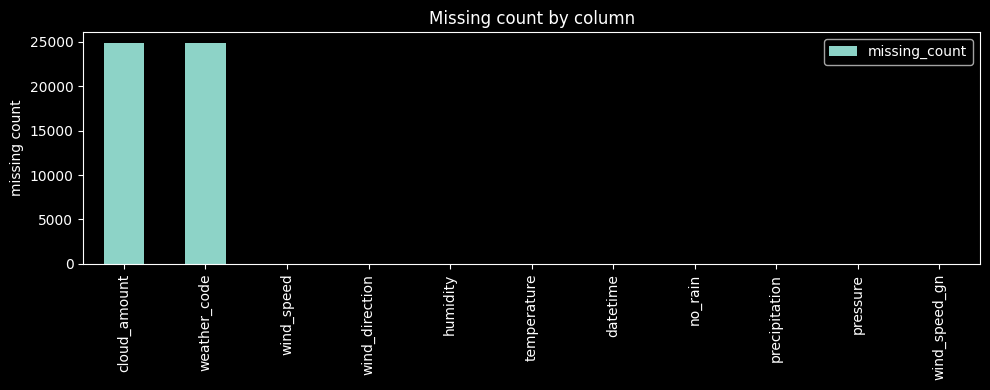

In [25]:
missing_count = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
display(missing_count)
missing_count.plot(kind="bar", figsize=(10,4), title="Missing count by column")
plt.ylabel("missing count")
plt.tight_layout()
plt.show()

## Missing data imputation / 欠損データの補完

欠損データで補完できそうな箇所を埋める

In [26]:
# 1. 雲量をグラデーションで埋める（線形補間）
df["cloud_amount"] = df["cloud_amount"].interpolate(method="linear")

# 2. 天気を前の状態で埋める（前方補完）
df["weather_code"] = df["weather_code"].ffill()

# 3. 先頭に残った空欄を、最初の有効データで遡って埋める
df[["cloud_amount", "weather_code"]] = df[["cloud_amount", "weather_code"]].bfill()

# 4. 欠損値確認
missing_count = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
display(missing_count)

,missing_count
wind_speed,7
wind_direction,7
humidity,2
temperature,1
datetime,0
precipitation,0
pressure,0
no_rain,0
wind_speed_gn,0
cloud_amount,0


## Delete unnecessary rows / 不要な行データの削除

データ補正が不可能で、数が少なく分析に影響がない場合は行データの削除を選択する

以下を確認する。

- 行が不自然に減ってないこと
- 欠損値が0であること

In [27]:
# 1. 欠損値を含む行を削除
df = df.dropna()

# 2. 欠損値確認
count = df.notna().sum().sort_values(ascending=False).to_frame("count")
missing_count = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
display(pd.concat([count, missing_count], axis=1))

,count,missing_count
datetime,35051,0
temperature,35051,0
humidity,35051,0
pressure,35051,0
precipitation,35051,0
no_rain,35051,0
wind_speed,35051,0
wind_direction,35051,0
wind_speed_gn,35051,0
cloud_amount,35051,0


## Time series plot / 気温の時系列を確認

ここでは以下を見る

- 夏に高く、冬に低い季節性が出ているか
- 途中でデータが途切れていないか
- 明らかに異常なスパイクがないか

In [28]:
daily_df = df.groupby(df["datetime"].dt.date).mean(numeric_only=True).reset_index()
daily_df = daily_df.rename(columns={"datetime":"date"})
display(daily_df.head())

,date,temperature,humidity,pressure,precipitation,no_rain,wind_speed,wind_speed_gn,cloud_amount,weather_code
0,2021-01-01,4.654545,39.590909,1010.309091,0.0,1.0,1.454545,1.0,0.022727,1.000
1,2021-01-02,4.854167,52.208333,1013.108333,0.0,1.0,2.120833,1.0,1.437500,1.125
2,2021-01-03,3.683333,51.708333,1019.200000,0.0,1.0,1.529167,1.0,4.083333,1.875
3,2021-01-04,5.720833,52.208333,1020.600000,0.0,1.0,1.858333,1.0,5.041667,2.125
4,2021-01-05,6.004167,66.416667,1016.237500,0.0,1.0,1.708333,1.0,9.583333,3.250


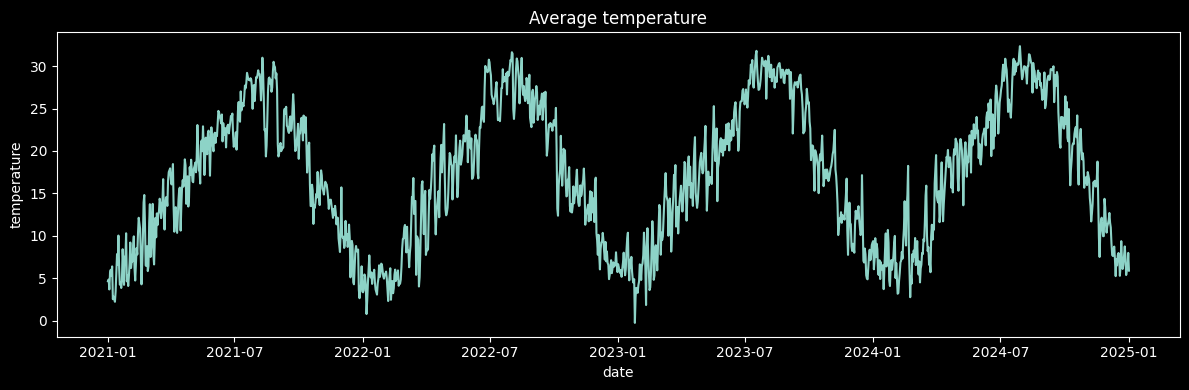

In [29]:
plt.figure(figsize=(12,4))
plt.plot(daily_df["date"], daily_df["temperature"], label="temperature")
plt.title("Average temperature")
plt.xlabel("date")
plt.ylabel("temperature")
plt.tight_layout()
plt.show()

## Distribution of weather codes / 天気コードの分布

最終的に天気コードを予測するということは、今回は分類問題。
クラスの偏りがかなり重要になる。

例えば「晴れ」「曇」「雨」ばかりで、「雪」「ひょう」「雷」がほとんどない場合、
モデルは珍しい天気をほぼ学習できない。

その場合は以下のような対応を検討する。

- レアな天気コードをまとめる
- 降水あり / なし のような粗い分類にする
- 評価指標を Accuracy（正解率） だけでなく F1スコア でも見る

In [30]:
weather_counts = df["weather_code"].value_counts().sort_index()
weather_summary = pd.DataFrame({
    "weather_code": weather_counts.index,
    "label": [JMA_WEATHER_CODES.get(int(c), "不明") for c in weather_counts.index],
    "count": weather_counts.values,
    "ratio": weather_counts.values / len(df),
})
weather_summary.sort_values(["count"], ascending=False)

,weather_code,label,count,ratio
3,4.0,曇,10265,0.292859
0,1.0,快晴,8838,0.252147
1,2.0,晴れ,7356,0.209866
5,10.0,雨,4517,0.128869
2,3.0,薄曇,3856,0.110011
9,15.0,雷,90,0.002568
4,9.0,霧雨,54,0.001541
7,12.0,雪,42,0.001198
6,11.0,みぞれ,30,0.000856
8,13.0,あられ,3,0.000086


In [31]:
# 晴天系: 1, 2, 3（視界良好）
# 曇天: 4, 5, 28（降水はないが、どんより）
# 雨: 9, 10, 16, 17, 101
# 雪・氷: 11, 12, 19, 22, 23, 24
# 雷: 15
# あられ・雹: 13, 14
# 特殊な気象災害系: 6, 7, 8
# でまとめる
grouping = {
    1: 1, 2: 1, 3: 1, # 晴天系
    4: 2, 5: 2, 28: 2, # 曇天
    9: 3, 10: 3, 16: 3, 17: 3, 101: 3, # 雨
    11: 4, 12: 4, 19: 4, 22: 4, 23: 4, 24: 4, # 雪・氷
    15: 5, # 雷
    13: 6, 14: 6, # あられ・雹
    6: 7, 7: 7, 8: 7, # 特殊・荒天
}
df["weather_class"] = df["weather_code"].map(grouping)
df["weather_class"].value_counts().sort_index()

weather_class
1    20050
2    10265
3     4571
4       72
5       90
6        3
Name: count, dtype: int64

### 天気グループのマスターテーブルを作る

In [32]:
group_labels = {
    1: "晴天系",
    2: "曇天",
    3: "雨",
    4: "雪・氷",
    5: "雷",
    6: "あられ・雹",
    7: "特殊・荒天"
}

df_weather_class = pd.DataFrame(grouping.items(), columns=["weather_code", "weather_class"])
df_weather_class["weather_label"] = df_weather_class["weather_class"].map(group_labels)
df_weather_class

,weather_code,weather_class,weather_label
0,1,1,晴天系
1,2,1,晴天系
2,3,1,晴天系
3,4,2,曇天
4,5,2,曇天
5,28,2,曇天
6,9,3,雨
7,10,3,雨
8,16,3,雨
9,17,3,雨


In [33]:
df_weather_class.to_csv("./data/m_weather_class.csv", index=False)

## Save data / 補正・整形したデータを保存

他のフェーズでも使いまわせるようにCSVとして保存する

In [34]:
df.to_csv("./data/all_data_after_eda.csv", index=False)